In [1]:
import torch
import transformer_lens
from transformer_lens import HookedTransformer
import numpy as np
import matplotlib.pyplot as plt

In [2]:
model = HookedTransformer.from_pretrained("gpt2")
model.eval()
print(model)

/home/baskar/Desktop/mi-probe-suite/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint(name='hook_embed')
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint(name='hook_pos_embed')
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln1.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln1.hook_normalized')
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln2.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln2.hook_normalized')
      )
      (attn): Attention(
        (hook_k): HookPoint(name='blocks.0.attn.hook_k')
        (hook_q): HookPoint(name='blocks.0.attn.hook_q')
        (hook_v): HookPoint(name='blocks.0.attn.hook_v')
        (hook_z): HookPoint(name='blocks.0.attn.hook_z')
        (hook_attn_scores): HookPoint(name='blocks.0.attn.hook_attn_scores')
        (hook_pattern): HookPoint(name='blocks.0.attn.hook_

In [3]:
prompt = "The capital of France is"
tokens = model.to_tokens(prompt)

print("Tokens:", tokens)
print("Token strings:", model.to_str_tokens(prompt))
print("Shape:", tokens.shape)

Tokens: tensor([[50256,   464,  3139,   286,  4881,   318]])
Token strings: ['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is']
Shape: torch.Size([1, 6])


In [4]:
logits, cache = model.run_with_cache(prompt)

print("Logits shape:", logits.shape)
print("Cache keys (first 10):", list(cache.keys())[:10])

Logits shape: torch.Size([1, 6, 50257])
Cache keys (first 10): ['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern']


In [5]:
# Get residual stream at every layer for this prompt
for layer in range(model.cfg.n_layers):
    residual = cache[f"blocks.{layer}.hook_resid_post"]
    print(f"Layer {layer} | shape: {residual.shape}")

Layer 0 | shape: torch.Size([1, 6, 768])
Layer 1 | shape: torch.Size([1, 6, 768])
Layer 2 | shape: torch.Size([1, 6, 768])
Layer 3 | shape: torch.Size([1, 6, 768])
Layer 4 | shape: torch.Size([1, 6, 768])
Layer 5 | shape: torch.Size([1, 6, 768])
Layer 6 | shape: torch.Size([1, 6, 768])
Layer 7 | shape: torch.Size([1, 6, 768])
Layer 8 | shape: torch.Size([1, 6, 768])
Layer 9 | shape: torch.Size([1, 6, 768])
Layer 10 | shape: torch.Size([1, 6, 768])
Layer 11 | shape: torch.Size([1, 6, 768])


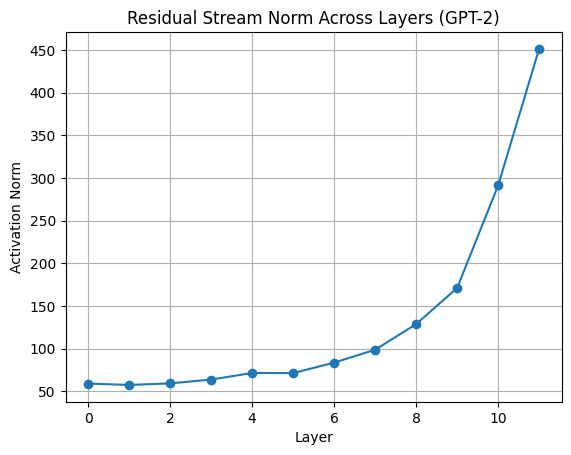

In [6]:
norms = []

for layer in range(model.cfg.n_layers):
    residual = cache[f"blocks.{layer}.hook_resid_post"]
    # Take last token position, compute L2 norm
    last_token = residual[0, -1, :]  # shape: (768,)
    norm = last_token.norm().item()
    norms.append(norm)

plt.plot(range(model.cfg.n_layers), norms, marker='o')
plt.xlabel("Layer")
plt.ylabel("Activation Norm")
plt.title("Residual Stream Norm Across Layers (GPT-2)")
plt.grid(True)
plt.savefig("../results/session1_activation_norms.png")
plt.show()

In [7]:
print("Num layers:", model.cfg.n_layers)
print("d_model:", model.cfg.d_model)
print("Num heads:", model.cfg.n_heads)
print("d_head:", model.cfg.d_head)

Num layers: 12
d_model: 768
Num heads: 12
d_head: 64
